In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 7)

In [2]:
precios = pd.read_csv('../data/precios_historicos.csv', index_col='Date', parse_dates=True)
tickers = precios.columns.tolist()
retornos_diarios = precios.pct_change().dropna()

dias_trading = 252
tasa_libre_riesgo = 0.05

# Retorno y volatilidad anualizados de cada activo individual
retorno_anual_activos = retornos_diarios.mean() * dias_trading
matriz_covarianza = retornos_diarios.cov() * dias_trading  # Covarianza anualizada

print("Activos en el portafolio:", tickers)
print("\nRetorno anual esperado por activo (%):")
print((retorno_anual_activos * 100).round(2))

Activos en el portafolio: ['GGAL', 'MELI', 'SPY', 'YPF']

Retorno anual esperado por activo (%):
GGAL    64.88
MELI    18.15
SPY     20.35
YPF     55.87
dtype: float64


In [3]:
np.random.seed(42)  # Para que los resultados sean reproducibles
num_portafolios = 10000
num_activos = len(tickers)

resultados = np.zeros((3, num_portafolios))  # Filas: retorno, volatilidad, sharpe
pesos_guardados = []

for i in range(num_portafolios):
    # Generamos pesos aleatorios que sumen 1 (100% del capital)
    pesos = np.random.random(num_activos)
    pesos = pesos / np.sum(pesos)
    pesos_guardados.append(pesos)

    # Retorno esperado del portafolio: suma ponderada de los retornos individuales
    retorno_portafolio = np.sum(pesos * retorno_anual_activos)

    # Volatilidad del portafolio: considera cómo se mueven los activos
    # entre sí (covarianza), no solo individualmente
    volatilidad_portafolio = np.sqrt(np.dot(pesos.T, np.dot(matriz_covarianza, pesos)))

    # Ratio Sharpe de este portafolio específico
    sharpe_portafolio = (retorno_portafolio - tasa_libre_riesgo) / volatilidad_portafolio

    resultados[0, i] = retorno_portafolio
    resultados[1, i] = volatilidad_portafolio
    resultados[2, i] = sharpe_portafolio

# Convertimos los resultados a un DataFrame para manipularlos más fácil
resultados_df = pd.DataFrame(resultados.T, columns=['Retorno', 'Volatilidad', 'Sharpe'])

print(f"\nSimulación completa: {num_portafolios} portafolios generados.")
print(resultados_df.describe())


Simulación completa: 10000 portafolios generados.
            Retorno   Volatilidad        Sharpe
count  10000.000000  10000.000000  10000.000000
mean       0.398720      0.342907      1.016779
std        0.066961      0.061095      0.078574
min        0.193038      0.157129      0.382302
25%        0.355379      0.301736      0.987901
50%        0.398852      0.339444      1.028786
75%        0.441342      0.379637      1.064820
max        0.627573      0.604895      1.217652


In [4]:
idx_max_sharpe = resultados_df['Sharpe'].idxmax()
pesos_max_sharpe = pesos_guardados[idx_max_sharpe]

# Portafolio de mínima varianza: el más conservador, prioriza bajo riesgo
idx_min_vol = resultados_df['Volatilidad'].idxmin()
pesos_min_vol = pesos_guardados[idx_min_vol]

print("\n" + "="*60)
print("PORTAFOLIO DE MÁXIMO SHARPE (mejor relación riesgo/retorno)")
print("="*60)
for ticker, peso in zip(tickers, pesos_max_sharpe):
    print(f"  {ticker}: {peso*100:.1f}%")
print(f"  Retorno esperado: {resultados_df.loc[idx_max_sharpe, 'Retorno']*100:.2f}%")
print(f"  Volatilidad: {resultados_df.loc[idx_max_sharpe, 'Volatilidad']*100:.2f}%")
print(f"  Sharpe: {resultados_df.loc[idx_max_sharpe, 'Sharpe']:.2f}")

print("\n" + "="*60)
print("PORTAFOLIO DE MÍNIMA VARIANZA (más conservador)")
print("="*60)
for ticker, peso in zip(tickers, pesos_min_vol):
    print(f"  {ticker}: {peso*100:.1f}%")
print(f"  Retorno esperado: {resultados_df.loc[idx_min_vol, 'Retorno']*100:.2f}%")
print(f"  Volatilidad: {resultados_df.loc[idx_min_vol, 'Volatilidad']*100:.2f}%")
print(f"  Sharpe: {resultados_df.loc[idx_min_vol, 'Sharpe']:.2f}")


PORTAFOLIO DE MÁXIMO SHARPE (mejor relación riesgo/retorno)
  GGAL: 3.9%
  MELI: 1.6%
  SPY: 74.3%
  YPF: 20.1%
  Retorno esperado: 29.21%
  Volatilidad: 19.88%
  Sharpe: 1.22

PORTAFOLIO DE MÍNIMA VARIANZA (más conservador)
  GGAL: 0.9%
  MELI: 0.1%
  SPY: 93.3%
  YPF: 5.8%
  Retorno esperado: 22.79%
  Volatilidad: 15.71%
  Sharpe: 1.13


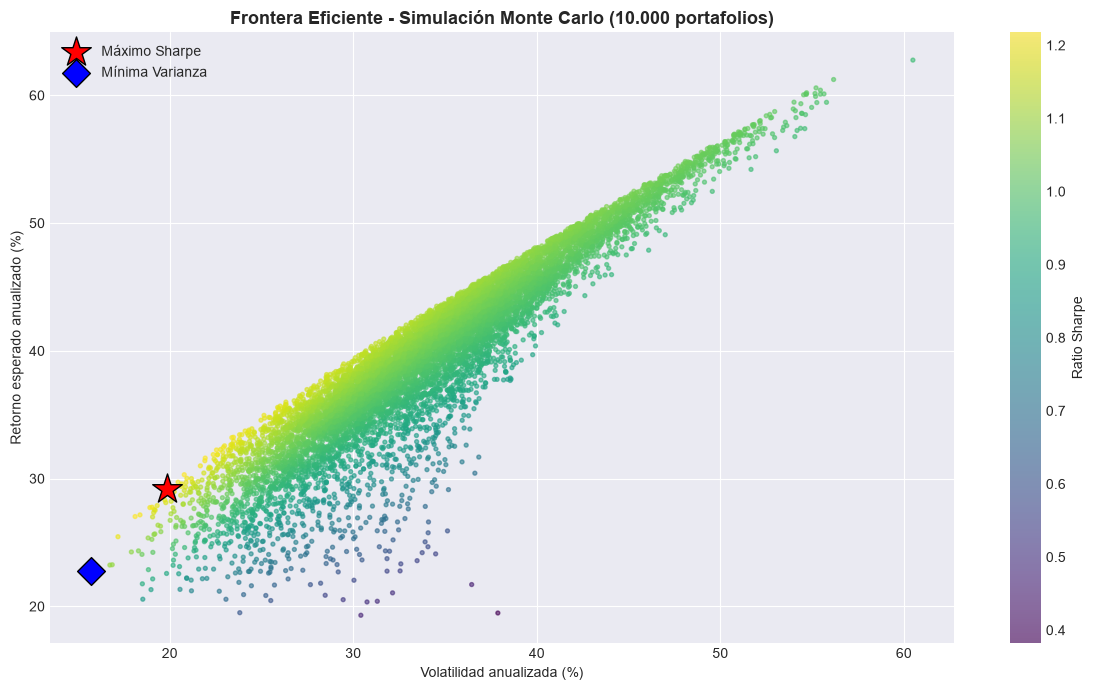

In [5]:
plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    resultados_df['Volatilidad'] * 100,
    resultados_df['Retorno'] * 100,
    c=resultados_df['Sharpe'],
    cmap='viridis',
    s=8,
    alpha=0.6
)
plt.colorbar(scatter, label='Ratio Sharpe')

# Marcamos el portafolio de máximo Sharpe con una estrella roja
plt.scatter(
    resultados_df.loc[idx_max_sharpe, 'Volatilidad'] * 100,
    resultados_df.loc[idx_max_sharpe, 'Retorno'] * 100,
    color='red', marker='*', s=500, edgecolors='black', linewidth=1,
    label='Máximo Sharpe'
)

# Marcamos el portafolio de mínima varianza con un diamante azul
plt.scatter(
    resultados_df.loc[idx_min_vol, 'Volatilidad'] * 100,
    resultados_df.loc[idx_min_vol, 'Retorno'] * 100,
    color='blue', marker='D', s=200, edgecolors='black', linewidth=1,
    label='Mínima Varianza'
)

plt.title('Frontera Eficiente - Simulación Monte Carlo (10.000 portafolios)', fontsize=13, fontweight='bold')
plt.xlabel('Volatilidad anualizada (%)')
plt.ylabel('Retorno esperado anualizado (%)')
plt.legend()
plt.tight_layout()
plt.savefig('../data/frontera_eficiente.png', dpi=150)
plt.show()

In [6]:
comparacion = pd.DataFrame({
    'Máximo Sharpe': pesos_max_sharpe,
    'Mínima Varianza': pesos_min_vol
}, index=tickers) * 100

comparacion.loc['Retorno esperado (%)'] = [
    resultados_df.loc[idx_max_sharpe, 'Retorno'] * 100,
    resultados_df.loc[idx_min_vol, 'Retorno'] * 100
]
comparacion.loc['Volatilidad (%)'] = [
    resultados_df.loc[idx_max_sharpe, 'Volatilidad'] * 100,
    resultados_df.loc[idx_min_vol, 'Volatilidad'] * 100
]
comparacion.loc['Ratio Sharpe'] = [
    resultados_df.loc[idx_max_sharpe, 'Sharpe'],
    resultados_df.loc[idx_min_vol, 'Sharpe']
]

print("\n" + "="*60)
print("TABLA COMPARATIVA: ASIGNACIÓN DE PESOS POR ESTRATEGIA (%)")
print("="*60)
print(comparacion.round(2))

comparacion.to_csv('../data/portafolios_optimos.csv')

print("\n✅ Notebook 4 completo. Proyecto de análisis de portafolio finalizado.")


TABLA COMPARATIVA: ASIGNACIÓN DE PESOS POR ESTRATEGIA (%)
                      Máximo Sharpe  Mínima Varianza
GGAL                           3.92             0.87
MELI                           1.65             0.07
SPY                           74.32            93.28
YPF                           20.12             5.79
Retorno esperado (%)          29.21            22.79
Volatilidad (%)               19.88            15.71
Ratio Sharpe                   1.22             1.13

✅ Notebook 4 completo. Proyecto de análisis de portafolio finalizado.


## Observaciones

- El portafolio de máximo Sharpe concentró el 74.32% del capital en SPY,
  seguido por YPF (20.12%), y solo un 3.92% y 1.65% en GGAL y MELI
  respectivamente. Esto confirma cuantitativamente lo observado en el
  notebook anterior: la simulación prioriza a SPY por su mejor relación
  riesgo/retorno individual, a pesar de que GGAL tuvo el mayor retorno
  bruto del período.

- El portafolio de mínima varianza llevó esta lógica al extremo,
  asignando un 93.28% a SPY y reduciendo a casi cero la exposición a
  MELI (0.07%) y GGAL (0.87%), priorizando la estabilidad por sobre
  el crecimiento.

- La comparación entre ambas estrategias muestra un trade-off claro:
  el portafolio de máximo Sharpe ofrece un retorno esperado mayor
  (29.21% vs. 22.79%) a cambio de asumir más volatilidad (19.88% vs.
  15.71%). La diferencia de Sharpe entre ambos (1.22 vs. 1.13) indica
  que, en este caso, vale la pena asumir ese riesgo adicional: se obtiene
  más retorno extra por unidad de riesgo en la estrategia de máximo Sharpe.